In [2]:
!pip install librosa matplotlib scipy numpy

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.fftpack import dct

In [4]:
from google.colab import files
uploaded = files.upload()

Saving audio.wav to audio.wav


In [5]:
filename = list(uploaded.keys())[0]
signal, sr = librosa.load(filename, sr=None)

print("Sampling Rate:", sr)
print("Signal Length:", len(signal))

Sampling Rate: 22050
Signal Length: 99229


Assignment 7.1

In [6]:
frame_size = int(0.025 * sr)  # 25 ms
frame = signal[:frame_size]

# Apply Hamming window
window = np.hamming(frame_size)
windowed_frame = frame * window

In [7]:
# DFT
dft = np.fft.fft(windowed_frame)
dft_magnitude = np.abs(dft)

# DCT
dct_coeffs = dct(windowed_frame, norm='ortho')
dct_magnitude = np.abs(dct_coeffs)

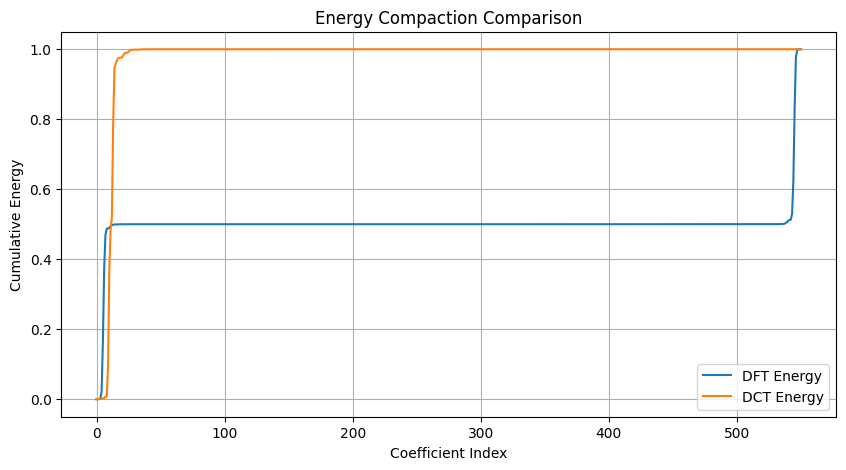

In [8]:
# Normalize energy
dft_energy = dft_magnitude**2
dct_energy = dct_magnitude**2

# Cumulative energy
dft_cum = np.cumsum(dft_energy) / np.sum(dft_energy)
dct_cum = np.cumsum(dct_energy) / np.sum(dct_energy)

# Plot cumulative energy
plt.figure(figsize=(10,5))
plt.plot(dft_cum, label='DFT Energy')
plt.plot(dct_cum, label='DCT Energy')
plt.title("Energy Compaction Comparison")
plt.xlabel("Coefficient Index")
plt.ylabel("Cumulative Energy")
plt.legend()
plt.grid()
plt.show()

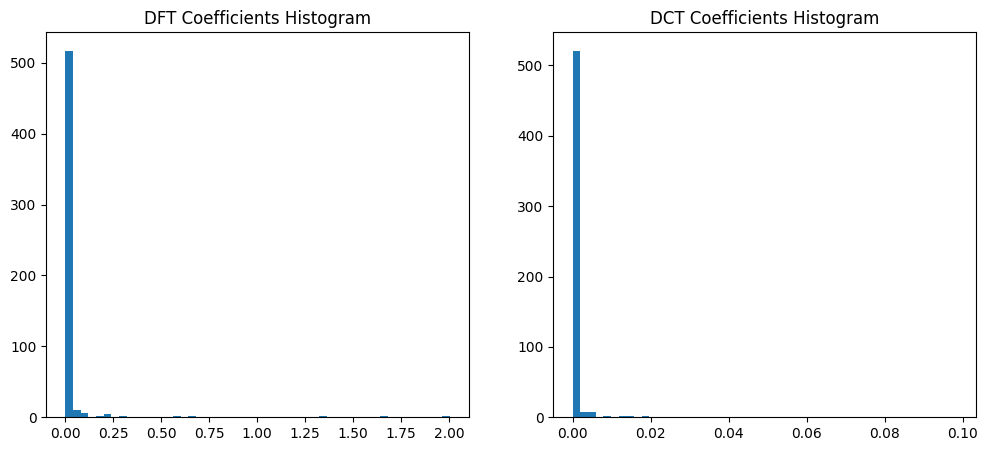

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(dft_magnitude, bins=50)
plt.title("DFT Coefficients Histogram")

plt.subplot(1,2,2)
plt.hist(dct_magnitude, bins=50)
plt.title("DCT Coefficients Histogram")

plt.show()

Assignment-7.2

In [10]:
mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
print("MFCC shape:", mfccs.shape)

MFCC shape: (13, 194)


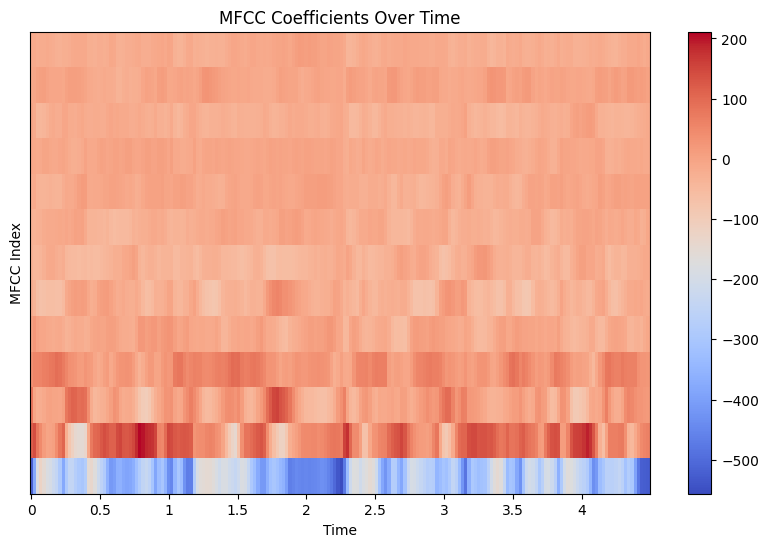

In [11]:
plt.figure(figsize=(10,6))
librosa.display.specshow(mfccs, x_axis='time')
plt.colorbar()
plt.title("MFCC Coefficients Over Time")
plt.xlabel("Time")
plt.ylabel("MFCC Index")
plt.show()

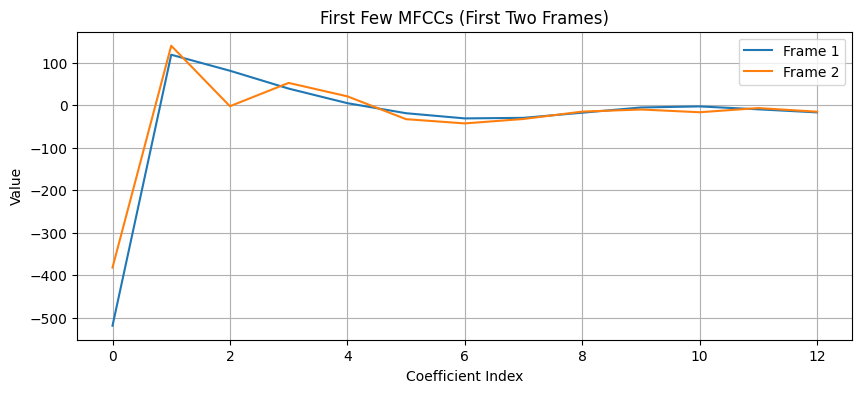

In [12]:
plt.figure(figsize=(10,4))

plt.plot(mfccs[:,0], label="Frame 1")
plt.plot(mfccs[:,1], label="Frame 2")

plt.title("First Few MFCCs (First Two Frames)")
plt.xlabel("Coefficient Index")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()